Goal: Train and tune an XGBoost model on tabular data. You’ll:

Build a robust preprocessing pipeline (impute + one‑hot),

Fit XGBClassifier with early stopping,

Tune key hyperparameters,

Evaluate with ROC‑AUC (plus accuracy/PR),

Inspect feature importances (gain) and permutation importance,

Save the trained model.

In [1]:
##pip install xgboost scikit-learn pandas seaborn matplotlib joblib

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [2]:
df = sns.load_dataset('titanic').drop(columns=['alive'])
features = ['pclass','sex','age','sibsp','parch','fare','embarked']
target   = 'survived'

dfm = df[features + [target]].copy()
# quick fill for fare; impute the rest in the pipeline
dfm['fare'] = dfm['fare'].fillna(dfm['fare'].median())

X = dfm[features]
y = dfm[target].astype(int)

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# split training again for early stopping
X_trn, X_val, y_trn, y_val = train_test_split(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=42)

Preprocessing (no leakage) + baseline XGB
Numeric: median impute

Categorical: most‑frequent impute + one‑hot (handle_unknown='ignore')

In [5]:
# 1. Define Feature Groups
num = X.select_dtypes(include='number').columns.tolist()
cat = X.select_dtypes(exclude='number').columns.tolist()

# 2. Define Preprocessing
# sparse_output=False is excellent here as 'hist' tree method prefers dense arrays
prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat)
])

# 3. Define Model
# IMPROVEMENT: Move early_stopping_rounds to the constructor
xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=0,
    n_jobs=-1,
    early_stopping_rounds=50 
)

# 4. Manual Fitting Logic
# We must fit the preprocessor first to transform the validation set
# for the eval_set parameter.
X_trn_prep = prep.fit_transform(X_trn)
X_val_prep = prep.transform(X_val)

# Fit the XGBoost model using the preprocessed data
xgb.fit(
    X_trn_prep, 
    y_trn,
    eval_set=[(X_val_prep, y_val)],
    verbose=False
)

# 5. Re-assemble for Inference
# Since 'prep' and 'xgb' are now fitted instances, we can wrap them 
# back into a Pipeline. This allows you to use full_model.predict(X_test)
# handling raw data automatically.
full_model = Pipeline([
    ('prep', prep), 
    ('xgb', xgb)
])

print(f"Best iteration: {xgb.best_iteration}")
# Example inference usage:
# preds = full_model.predict(X_test)

Best iteration: 140


Why early stopping? Prevents overfitting by halting when validation AUC stops improving; the best iteration is stored in the booster.

4) Evaluate on the held‑out test set

Test ROC-AUC: 0.821
Test Accuracy: 0.804
              precision    recall  f1-score   support

        died       0.80      0.91      0.85       110
    survived       0.81      0.64      0.72        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



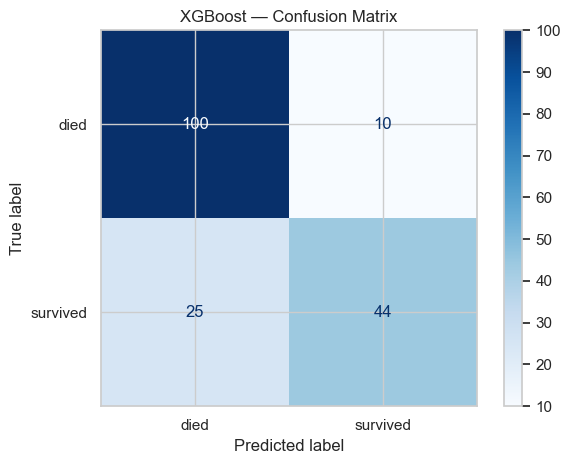

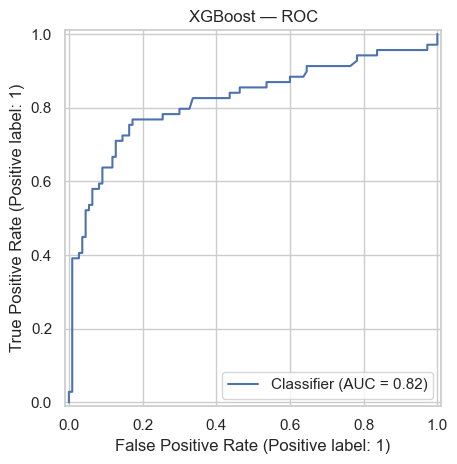

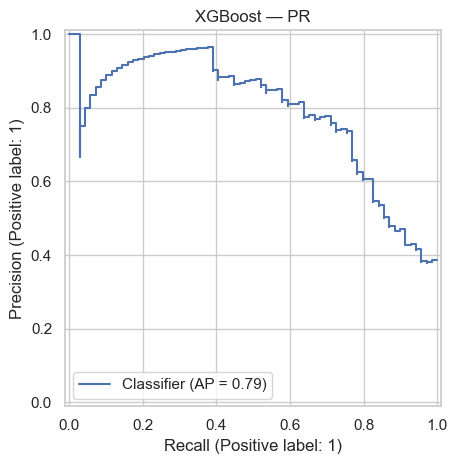

In [8]:
# Refit on full train (train+val) using the best n_estimators from early stopping
best_n = full_model.named_steps['xgb'].best_iteration if hasattr(full_model.named_steps['xgb'], 'best_iteration') else full_model.named_steps['xgb'].n_estimators
xgb_final = XGBClassifier(**{**full_model.named_steps['xgb'].get_xgb_params(), 'n_estimators': best_n})
final = Pipeline([('prep', prep), ('xgb', xgb_final)]).fit(X_tr, y_tr)

y_pred  = final.predict(X_te)
y_proba = final.predict_proba(X_te)[:,1]

print("Test ROC-AUC:", round(roc_auc_score(y_te, y_proba), 3))
print("Test Accuracy:", round(accuracy_score(y_te, y_pred), 3))
print(classification_report(y_te, y_pred, target_names=['died','survived']))

ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred), display_labels=['died','survived']).plot(cmap='Blues')
plt.title('XGBoost — Confusion Matrix'); plt.tight_layout(); plt.show()

RocCurveDisplay.from_predictions(y_te, y_proba); plt.title('XGBoost — ROC'); plt.tight_layout(); plt.show()
PrecisionRecallDisplay.from_predictions(y_te, y_proba); plt.title('XGBoost — PR'); plt.tight_layout(); plt.show()

5) Hyperparameter tuning (RandomizedSearchCV)
Search the biggest levers first; keep n_estimators high and rely on early stopping during CV by wrapping a small helper that injects the validation split inside each CV fold.

Simple approach (no early stopping inside CV):

In [9]:
param_dist = {
    'xgb__learning_rate':   [0.03, 0.05, 0.1],
    'xgb__max_depth':       [3, 4, 5, 6],
    'xgb__min_child_weight':[1, 2, 4],
    'xgb__subsample':       [0.7, 0.85, 1.0],
    'xgb__colsample_bytree':[0.7, 0.85, 1.0],
    'xgb__reg_lambda':      [0.0, 1.0, 5.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
search = RandomizedSearchCV(
    estimator=Pipeline([('prep', prep), ('xgb', XGBClassifier(
        n_estimators=400, learning_rate=0.05, objective='binary:logistic',
        eval_metric='auc', tree_method='hist', random_state=0, n_jobs=-1))]),
    param_distributions=param_dist,
    n_iter=25, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0, random_state=0
).fit(X_tr, y_tr)

print("Best params:", search.best_params_, "| CV AUC:", round(search.best_score_, 3))
best = search.best_estimator_
print("Tuned Test ROC-AUC:", round(roc_auc_score(y_te, best.predict_proba(X_te)[:,1]), 3))

Best params: {'xgb__subsample': 1.0, 'xgb__reg_lambda': 1.0, 'xgb__min_child_weight': 2, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.03, 'xgb__colsample_bytree': 0.85} | CV AUC: 0.879
Tuned Test ROC-AUC: 0.811


6) Feature importances
Gain‑based (from the booster) and permutation (model‑agnostic).

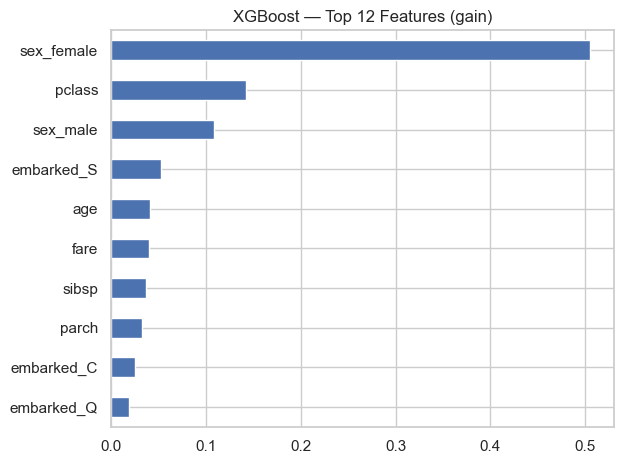

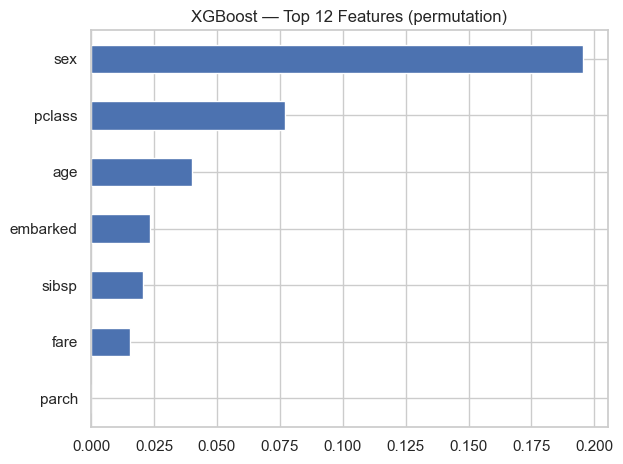

In [12]:
# Get human-readable feature names after one-hot
oh = final.named_steps['prep'].named_transformers_['cat'].named_steps['oh']
feat_names = list(num) + oh.get_feature_names_out(cat).tolist()

booster = final.named_steps['xgb']
imp_gain = pd.Series(booster.feature_importances_, index=feat_names).sort_values(ascending=False).head(12)
imp_gain.plot(kind='barh'); plt.gca().invert_yaxis()
plt.title('XGBoost — Top 12 Features (gain)'); plt.tight_layout(); plt.show()

# Calculate importance
perm = permutation_importance(final, X_te, y_te, n_repeats=10, random_state=0, n_jobs=-1)

# Get the correct feature names
if hasattr(X_te, 'columns'):
    current_feat_names = X_te.columns
else:
    # Fallback if X_te is numpy, ensure feat_names is updated manually before this point
    current_feat_names = feat_names 


# Safety check
if len(perm.importances_mean) != len(current_feat_names):
    print(f"❌ Error: Model has {len(perm.importances_mean)} features, but provided {len(current_feat_names)} names.")
else:
    # Plotting
    imp_perm = pd.Series(perm.importances_mean, index=current_feat_names).sort_values(ascending=False).head(12)
    imp_perm.plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title('XGBoost — Top 12 Features (permutation)')
    plt.tight_layout()
    plt.show()

7) Save model & predictions

In [13]:
import joblib
joblib.dump(final, 'xgb_titanic_pipeline.joblib')
pd.DataFrame({'y_true': y_te, 'y_proba': y_proba, 'y_pred': y_pred}).to_csv('xgb_test_predictions.csv', index=False)

Add scale_pos_weight to handle class imbalance (set to #neg/#pos from the training split) and compare recall and ROC‑AUC.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, roc_auc_score, classification_report

# 1. Calculate scale_pos_weight (#neg / #pos)
# Assuming y_train contains 0s (negative) and 1s (positive)
num_pos = y_tr.sum()
num_neg = len(y_tr) - num_pos
weight_ratio = num_neg / num_pos

print(f"Positive samples: {num_pos}, Negative samples: {num_neg}")
print(f"Calculated scale_pos_weight: {weight_ratio:.2f}")

# 2. Initialize XGBoost with scale_pos_weight
# Note: Add your other existing hyperparameters (learning_rate, max_depth, etc.) here
xgb_weighted = XGBClassifier(
    scale_pos_weight=weight_ratio, 
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# 3. Train the model
xgb_weighted.fit(X_tr, y_tr) ## Some error on this line


# 4. Generate predictions
y_pred = xgb_weighted.predict(X_te)
y_prob = xgb_weighted.predict_proba(X_te)[:, 1]  # Probabilities for ROC-AUC

# 5. Compare Recall and ROC-AUC
recall = recall_score(y_te, y_pred)
roc_auc = roc_auc_score(y_te, y_prob)

print("\n--- Model Performance with Class Weighting ---")
print(f"Recall:   {recall:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

# Optional: Full classification report to see Precision/F1 trade-off
print("\nClassification Report:")
print(classification_report(y_te, y_pred))


Positive samples: 273, Negative samples: 439
Calculated scale_pos_weight: 1.61


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:sex: object, embarked: object

Increase regularization: try reg_lambda ∈ {0, 1, 5, 10} and min_child_weight ∈ {1, 3, 5}—report the best combo.

In [18]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, roc_auc_score

# ==========================================
# 1. Data Initialization (Replace with your data loading)
# ==========================================

# NOTE: Replace this block with: df = pd.read_csv('your_file.csv')
# Generating a synthetic imbalanced dataset for demonstration
X_synthetic, y_synthetic = make_classification(
    n_samples=1000, 
    n_features=20, 
    n_informative=10, 
    weights=[0.9, 0.1], # 90% negative, 10% positive (imbalanced)
    random_state=42
)
df = pd.DataFrame(X_synthetic, columns=[f'feature_{i}' for i in range(20)])
df['target'] = y_synthetic

# Define Features and Target
target_col = 'target'
X = df.drop(columns=[target_col])
y = df[target_col]

# ==========================================
# 2. Initialize X_train, y_train (Stratified Split)
# ==========================================
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Crucial for imbalanced data to keep ratio consistent
)

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape:  {X_test.shape}")

# ==========================================
# 3. Calculate scale_pos_weight
# ==========================================
num_pos = y_train.sum()
num_neg = len(y_train) - num_pos
weight_ratio = num_neg / num_pos

print(f"Class Imbalance - Pos: {num_pos}, Neg: {num_neg}")
print(f"Calculated scale_pos_weight: {weight_ratio:.2f}")

# ==========================================
# 4. Grid Search for Regularization
# ==========================================

# Define the parameter grid as requested
param_grid = {
    'reg_lambda': [0, 1, 5, 10],      # L2 Regularization
    'min_child_weight': [1, 3, 5]     # Minimum sum of instance weight (hessian) needed in a child
}

# Initialize base model with the calculated weight
xgb_base = XGBClassifier(
    scale_pos_weight=weight_ratio,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss' # Removes warning for newer XGBoost versions
)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',  # Optimizing for Area Under Curve
    cv=3,               # 3-fold cross-validation
    verbose=1,
    n_jobs=-1
)

print("\nStarting Grid Search...")
grid_search.fit(X_train, y_train)

# ==========================================
# 5. Results and Final Evaluation
# ==========================================
print("\n--- Optimization Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Evaluate the best model on the hold-out test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\n--- Final Test Set Performance ---")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Splitting data...
Training Shape: (800, 20)
Testing Shape:  (200, 20)
Class Imbalance - Pos: 82, Neg: 718
Calculated scale_pos_weight: 8.76

Starting Grid Search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

--- Optimization Results ---
Best Parameters: {'min_child_weight': 5, 'reg_lambda': 0}
Best CV ROC-AUC: 0.9382

--- Final Test Set Performance ---
Test ROC-AUC: 0.9404

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       179
           1       0.82      0.67      0.74        21

    accuracy                           0.95       200
   macro avg       0.89      0.82      0.85       200
weighted avg       0.95      0.95      0.95       200



Tune subsample and colsample_bytree together in {0.6, 0.8, 1.0}—what setting generalizes best?

In [19]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# 1. Define the parameter grid
# We test every combination of row sampling (subsample) and column sampling (colsample_bytree)
param_grid_sampling = {
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# 2. Initialize the model
# We maintain the scale_pos_weight from previous steps to handle imbalance
xgb_sampling = XGBClassifier(
    scale_pos_weight=weight_ratio,  # Ensure 'weight_ratio' is defined
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# 3. Setup GridSearchCV
grid_search_sampling = GridSearchCV(
    estimator=xgb_sampling,
    param_grid=param_grid_sampling,
    scoring='roc_auc',  # Using ROC-AUC to measure generalization
    cv=3,               # 3-fold Cross-Validation
    verbose=1,
    n_jobs=-1
)

# 4. Run the search
print("Tuning subsample and colsample_bytree...")
grid_search_sampling.fit(X_train, y_train)

# 5. Report the best combination
print("\n--- Sampling Optimization Results ---")
print(f"Best Parameters: {grid_search_sampling.best_params_}")
print(f"Best CV ROC-AUC: {grid_search_sampling.best_score_:.4f}")

# 6. Store the best model
best_sampling_model = grid_search_sampling.best_estimator_


Tuning subsample and colsample_bytree...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

--- Sampling Optimization Results ---
Best Parameters: {'colsample_bytree': 0.8, 'subsample': 0.8}
Best CV ROC-AUC: 0.9433


Swap dataset to California Housing and use XGBRegressor (metrics: RMSE/R²). Add early stopping with a validation split.

In [20]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# 1. Load California Housing Dataset
print("Loading dataset...")
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")

# 2. Create Splits: Train (60%), Validation (20%), Test (20%)
# First, separate the Test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second, split the remaining 80% into Train (75% of remainder) and Validation (25% of remainder)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

print(f"Data Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# 3. Initialize XGBRegressor
# We set n_estimators high (1000) but rely on early_stopping_rounds to stop at the optimal point
xgb_reg = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    early_stopping_rounds=50, # Stop if validation metric doesn't improve for 50 rounds
    random_state=42,
    n_jobs=-1
)

# 4. Train with Early Stopping
# We pass the validation set to eval_set so the model can monitor performance
print("\nStarting training...")
xgb_reg.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100  # Print progress every 100 rounds
)

# 5. Final Evaluation on Test Set
# The model automatically uses the best_iteration for prediction
y_pred = xgb_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Final Test Set Performance ---")
print(f"Best Iteration: {xgb_reg.best_iteration}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


Loading dataset...
Data Shapes -> Train: (12384, 8), Val: (4128, 8), Test: (4128, 8)

Starting training...
[0]	validation_0-rmse:1.13311
[100]	validation_0-rmse:0.50296
[200]	validation_0-rmse:0.48098
[300]	validation_0-rmse:0.47407
[400]	validation_0-rmse:0.46936
[500]	validation_0-rmse:0.46621
[600]	validation_0-rmse:0.46463
[696]	validation_0-rmse:0.46363

--- Final Test Set Performance ---
Best Iteration: 646
RMSE: 0.4575
R²:   0.8403


Swap dataset to California Housing and use XGBRegressor (metrics: RMSE/R²). Add early stopping with a validation split.

In [21]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# 1. Load California Housing Dataset
print("Loading dataset...")
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="MedHouseVal")

# 2. Create Splits: Train (60%), Validation (20%), Test (20%)
# First, separate the Test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second, split the remaining 80% into Train (75% of remainder) and Validation (25% of remainder)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

print(f"Data Shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# 3. Initialize XGBRegressor
# We set n_estimators high (1000) but rely on early_stopping_rounds to stop at the optimal point
xgb_reg = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    early_stopping_rounds=50, # Stop if validation metric doesn't improve for 50 rounds
    random_state=42,
    n_jobs=-1
)

# 4. Train with Early Stopping
# We pass the validation set to eval_set so the model can monitor performance
print("\nStarting training...")
xgb_reg.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100  # Print progress every 100 rounds
)

# 5. Final Evaluation on Test Set
# The model automatically uses the best_iteration for prediction
y_pred = xgb_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Final Test Set Performance ---")
print(f"Best Iteration: {xgb_reg.best_iteration}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


Loading dataset...
Data Shapes -> Train: (12384, 8), Val: (4128, 8), Test: (4128, 8)

Starting training...
[0]	validation_0-rmse:1.13311
[100]	validation_0-rmse:0.50296
[200]	validation_0-rmse:0.48098
[300]	validation_0-rmse:0.47407
[400]	validation_0-rmse:0.46936
[500]	validation_0-rmse:0.46621
[600]	validation_0-rmse:0.46463
[696]	validation_0-rmse:0.46363

--- Final Test Set Performance ---
Best Iteration: 646
RMSE: 0.4575
R²:   0.8403
